### Imports

In [1]:
# ============================================
# CELL 1 — IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

import joblib

### Load Dataset

In [4]:
# ============================================
# CELL 2 — LOAD DATASET
# ============================================

file_path = "D:/All_Projects/SOC/uncertainty_aware_soc_dataset_30000.csv"
df = pd.read_csv(file_path)

df.head()

,device_id,device_type,department,criticality_level,firmware_version,cpu_usage_percent,memory_usage_percent,disk_write_mb_per_min,disk_read_mb_per_min,process_spawn_count,...,outbound_traffic_mb,inbound_traffic_mb,unique_external_ips,dns_request_count,unusual_port_flag,privilege_escalation_flag,configuration_change_flag,antivirus_alert_flag,failed_auth_attempts,stage_label
0,D264,mri,Ward,1,v1.0,23.894167,33.293337,34.138354,55.016772,3,...,32.973930,33.301706,0,11,0,0,0,0,1,stable
1,D078,mri,ICU,2,v1.0,43.950325,53.320795,215.234357,89.160621,10,...,8.220715,18.169073,1,4,0,0,1,0,1,maintenance
2,D233,mri,ER,1,v3.0,25.178097,52.545221,40.611329,276.471505,12,...,82.999052,17.101102,0,11,0,0,0,0,2,backup_sync
3,D059,patient_monitor,ER,3,v1.0,30.579321,31.527723,26.491821,92.515771,10,...,28.757142,40.313303,0,19,0,0,0,1,0,false_positive
4,D277,mri,ER,1,v4.0,31.850350,32.857862,16.564265,96.541457,1,...,11.750125,26.512912,0,3,0,0,0,0,2,stable


### Create Binary Anomaly Label

In [5]:
# ============================================
# CELL 3 — CREATE ANOMALY LABEL
# ============================================

anomaly_stages = [
    "encryption",
    "propagation",
    "slow_stealth",
    "network_only",
    "privilege_attempt"
]

df["anomaly"] = df["stage_label"].apply(
    lambda x: 1 if x in anomaly_stages else 0
)

df["anomaly"].value_counts()

anomaly
0    26400
1     3600
Name: count, dtype: int64

### Encode Categorical Features

In [6]:
# ============================================
# CELL 4 — ENCODE CATEGORICAL FEATURES
# ============================================

categorical_cols = [
    "device_id",
    "device_type",
    "department",
    "firmware_version"
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()

,device_id,device_type,department,criticality_level,firmware_version,cpu_usage_percent,memory_usage_percent,disk_write_mb_per_min,disk_read_mb_per_min,process_spawn_count,...,inbound_traffic_mb,unique_external_ips,dns_request_count,unusual_port_flag,privilege_escalation_flag,configuration_change_flag,antivirus_alert_flag,failed_auth_attempts,stage_label,anomaly
0,263,1,3,1,0,23.894167,33.293337,34.138354,55.016772,3,...,33.301706,0,11,0,0,0,0,1,stable,0
1,77,1,1,2,0,43.950325,53.320795,215.234357,89.160621,10,...,18.169073,1,4,0,0,1,0,1,maintenance,0
2,232,1,0,1,2,25.178097,52.545221,40.611329,276.471505,12,...,17.101102,0,11,0,0,0,0,2,backup_sync,0
3,58,2,0,3,0,30.579321,31.527723,26.491821,92.515771,10,...,40.313303,0,19,0,0,0,1,0,false_positive,0
4,276,1,0,1,3,31.850350,32.857862,16.564265,96.541457,1,...,26.512912,0,3,0,0,0,0,2,stable,0


### Train/Test Split

In [7]:
# ============================================
# CELL 5 — SPLIT DATA
# ============================================

X = df.drop(columns=["stage_label", "anomaly"])
y = df["anomaly"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (24000, 23)
Test size: (6000, 23)


### Train Supervised Model (Random Forest)

In [8]:
# ============================================
# CELL 6 — TRAIN RANDOM FOREST
# ============================================

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_prob = rf.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.5).astype(int)

### Train Unsupervised Model

In [9]:
# ============================================
# CELL 7 — TRAIN ISOLATION FOREST
# ============================================

iso = IsolationForest(
    contamination=0.08,
    random_state=42
)

iso.fit(X_train)

deviation_scores = -iso.decision_function(X_test)

# Normalize deviation score to 0–1
deviation_scores = (deviation_scores - deviation_scores.min()) / \
                   (deviation_scores.max() - deviation_scores.min())

### Evaluation Metrics

In [10]:
# ============================================
# CELL 8 — MODEL EVALUATION
# ============================================

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(accuracy, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0
ROC-AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5280
           1       1.00      1.00      1.00       720

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000

Confusion Matrix:

[[5280    0]
 [   0  720]]


### ROC Curve

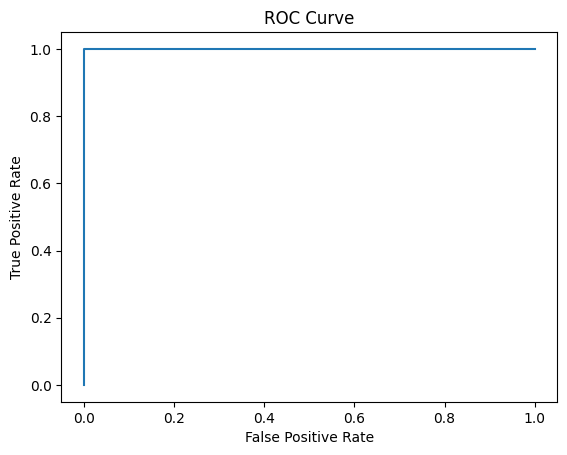

In [11]:
# ============================================
# CELL 9 — ROC CURVE
# ============================================

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

### Feature Importance

encrypted_extension_ratio    0.171456
file_entropy_avg             0.165456
privilege_escalation_flag    0.164037
failed_auth_attempts         0.090350
file_rename_count            0.079547
outbound_traffic_mb          0.073707
unique_external_ips          0.070309
unusual_port_flag            0.061583
dns_request_count            0.056077
configuration_change_flag    0.023226
disk_write_mb_per_min        0.016303
disk_read_mb_per_min         0.012754
memory_usage_percent         0.005114
cpu_usage_percent            0.004646
antivirus_alert_flag         0.003032
dtype: float64


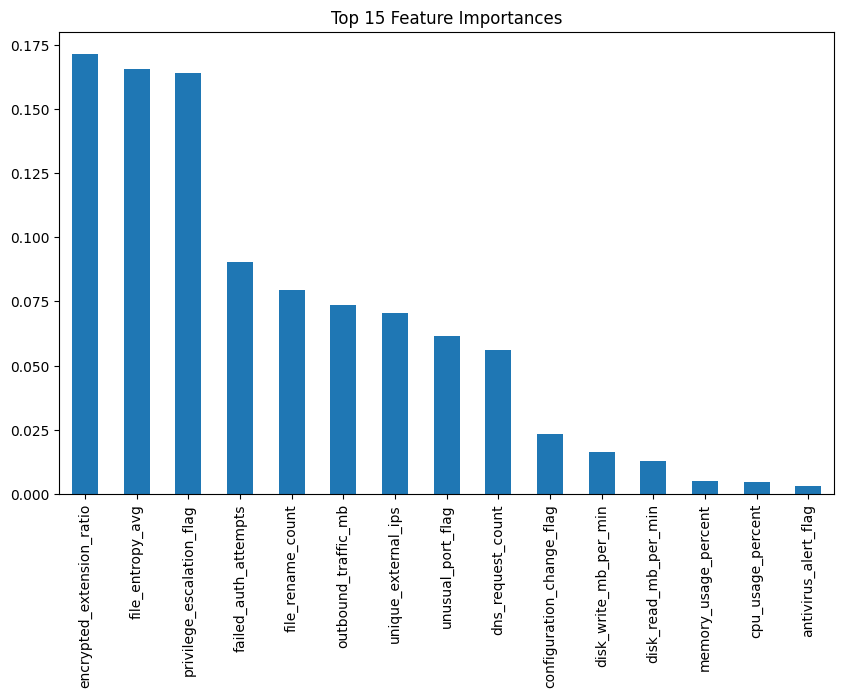

In [12]:
# ============================================
# CELL 10 — FEATURE IMPORTANCE
# ============================================

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances.head(15))

plt.figure(figsize=(10,6))
importances.head(15).plot(kind="bar")
plt.title("Top 15 Feature Importances")
plt.show()

### Compute Uncertainty

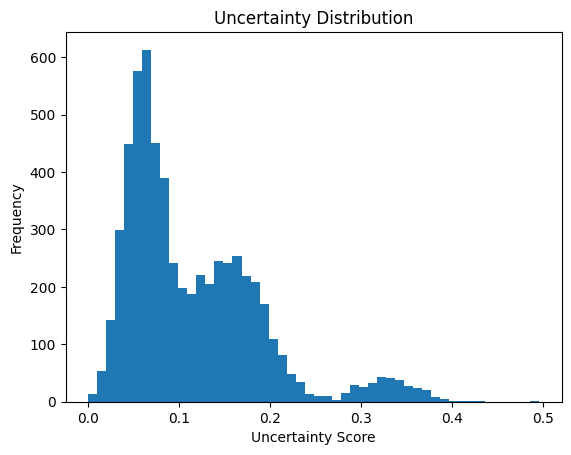

In [13]:
# ============================================
# CELL 11 — UNCERTAINTY COMPUTATION
# ============================================

epsilon = 1e-9

entropy = - (y_prob * np.log(y_prob + epsilon) +
             (1 - y_prob) * np.log(1 - y_prob + epsilon))

hybrid_disagreement = np.abs(y_prob - deviation_scores)

uncertainty = (entropy + hybrid_disagreement) / 2

plt.figure()
plt.hist(uncertainty, bins=50)
plt.title("Uncertainty Distribution")
plt.xlabel("Uncertainty Score")
plt.ylabel("Frequency")
plt.show()

### Save Model

In [15]:
# ============================================
# CELL 12 — SAVE MODELS
# ============================================

joblib.dump(rf, "rf_anomaly_model.pkl")
joblib.dump(iso, "iso_anomaly_model.pkl")

print("Models saved successfully.")

Models saved successfully.


### Helper Function for Testing

In [16]:
# ============================================
# CELL 13 — TEST HELPER FUNCTION
# ============================================

def evaluate_case(test_input_dict):
    
    # Convert to DataFrame
    test_df = pd.DataFrame([test_input_dict])
    
    # Encode categorical columns using trained encoders
    for col in categorical_cols:
        test_df[col] = encoders[col].transform(test_df[col])
    
    # Predict supervised probability
    prob = rf.predict_proba(test_df)[0][1]
    
    # Unsupervised deviation
    deviation = -iso.decision_function(test_df)[0]
    
    # Normalize deviation using same logic
    deviation = (deviation - deviation_scores.min()) / \
                (deviation_scores.max() - deviation_scores.min())
    
    # Entropy uncertainty
    epsilon = 1e-9
    entropy = - (prob * np.log(prob + epsilon) + 
                 (1 - prob) * np.log(1 - prob + epsilon))
    
    disagreement = abs(prob - deviation)
    uncertainty = (entropy + disagreement) / 2
    
    print("Anomaly Probability:", round(prob, 4))
    print("Deviation Score:", round(deviation, 4))
    print("Uncertainty Score:", round(uncertainty, 4))
    
    # SOC Decision Logic
    if prob > 0.8 and uncertainty < 0.2:
        print("SOC Decision: AUTO-CONTAIN")
    elif uncertainty > 0.3:
        print("SOC Decision: ESCALATE TO HUMAN")
    else:
        print("SOC Decision: MONITOR")

### TEST CASE 1 — Clear Encryption Attack

In [17]:
# ============================================
# TEST CASE 1 — ENCRYPTION
# ============================================

test_case_1 = {
    "device_id": "D010",
    "device_type": "ventilator",
    "department": "ICU",
    "criticality_level": 5,
    "firmware_version": "v2.0",

    "cpu_usage_percent": 92,
    "memory_usage_percent": 88,
    "disk_write_mb_per_min": 800,
    "disk_read_mb_per_min": 120,
    "process_spawn_count": 70,

    "file_rename_count": 1200,
    "new_file_creation_count": 500,
    "file_entropy_avg": 7.9,
    "encrypted_extension_ratio": 0.9,

    "outbound_traffic_mb": 30,
    "inbound_traffic_mb": 40,
    "unique_external_ips": 2,
    "dns_request_count": 15,
    "unusual_port_flag": 0,

    "privilege_escalation_flag": 1,
    "configuration_change_flag": 1,
    "antivirus_alert_flag": 1,
    "failed_auth_attempts": 12
}

evaluate_case(test_case_1)

Anomaly Probability: 0.89
Deviation Score: 0.1724
Uncertainty Score: 0.532
SOC Decision: ESCALATE TO HUMAN


### TEST CASE 2 — Maintenance (Ambiguous)

In [18]:
# ============================================
# TEST CASE 2 — MAINTENANCE
# ============================================

test_case_2 = {
    "device_id": "D200",
    "device_type": "mri",
    "department": "Radiology",
    "criticality_level": 4,
    "firmware_version": "v4.0",

    "cpu_usage_percent": 55,
    "memory_usage_percent": 60,
    "disk_write_mb_per_min": 250,
    "disk_read_mb_per_min": 100,
    "process_spawn_count": 25,

    "file_rename_count": 40,
    "new_file_creation_count": 60,
    "file_entropy_avg": 6.2,
    "encrypted_extension_ratio": 0.0,

    "outbound_traffic_mb": 25,
    "inbound_traffic_mb": 70,
    "unique_external_ips": 1,
    "dns_request_count": 20,
    "unusual_port_flag": 0,

    "privilege_escalation_flag": 0,
    "configuration_change_flag": 1,
    "antivirus_alert_flag": 0,
    "failed_auth_attempts": 1
}

evaluate_case(test_case_2)

Anomaly Probability: 0.01
Deviation Score: -0.0086
Uncertainty Score: 0.0373
SOC Decision: MONITOR


### TEST CASE 3 — Slow Stealth Ransomware

In [19]:
# ============================================
# TEST CASE 3 — SLOW STEALTH
# ============================================

test_case_3 = {
    "device_id": "D150",
    "device_type": "patient_monitor",
    "department": "ICU",
    "criticality_level": 4,
    "firmware_version": "v3.0",

    "cpu_usage_percent": 60,
    "memory_usage_percent": 65,
    "disk_write_mb_per_min": 180,
    "disk_read_mb_per_min": 140,
    "process_spawn_count": 30,

    "file_rename_count": 90,
    "new_file_creation_count": 120,
    "file_entropy_avg": 7.1,
    "encrypted_extension_ratio": 0.45,

    "outbound_traffic_mb": 70,
    "inbound_traffic_mb": 60,
    "unique_external_ips": 3,
    "dns_request_count": 35,
    "unusual_port_flag": 0,

    "privilege_escalation_flag": 1,
    "configuration_change_flag": 0,
    "antivirus_alert_flag": 0,
    "failed_auth_attempts": 3
}

evaluate_case(test_case_3)

Anomaly Probability: 0.865
Deviation Score: 0.09
Uncertainty Score: 0.5854
SOC Decision: ESCALATE TO HUMAN


### TEST CASE 4 — Network-Only Attack

In [20]:
# ============================================
# TEST CASE 4 — NETWORK ATTACK
# ============================================

test_case_4 = {
    "device_id": "D099",
    "device_type": "infusion_pump",
    "department": "Ward",
    "criticality_level": 2,
    "firmware_version": "v1.0",

    "cpu_usage_percent": 45,
    "memory_usage_percent": 50,
    "disk_write_mb_per_min": 50,
    "disk_read_mb_per_min": 80,
    "process_spawn_count": 10,

    "file_rename_count": 2,
    "new_file_creation_count": 5,
    "file_entropy_avg": 5.5,
    "encrypted_extension_ratio": 0.0,

    "outbound_traffic_mb": 650,
    "inbound_traffic_mb": 120,
    "unique_external_ips": 25,
    "dns_request_count": 120,
    "unusual_port_flag": 1,

    "privilege_escalation_flag": 0,
    "configuration_change_flag": 0,
    "antivirus_alert_flag": 0,
    "failed_auth_attempts": 0
}

evaluate_case(test_case_4)

Anomaly Probability: 0.98
Deviation Score: 0.1026
Uncertainty Score: 0.4877
SOC Decision: ESCALATE TO HUMAN


### TEST CASE 5 — Normal Stable Device

In [21]:
# ============================================
# TEST CASE 5 — NORMAL
# ============================================

test_case_5 = {
    "device_id": "D300",
    "device_type": "infusion_pump",
    "department": "Ward",
    "criticality_level": 2,
    "firmware_version": "v2.0",

    "cpu_usage_percent": 35,
    "memory_usage_percent": 40,
    "disk_write_mb_per_min": 20,
    "disk_read_mb_per_min": 50,
    "process_spawn_count": 5,

    "file_rename_count": 1,
    "new_file_creation_count": 3,
    "file_entropy_avg": 5.3,
    "encrypted_extension_ratio": 0.0,

    "outbound_traffic_mb": 10,
    "inbound_traffic_mb": 20,
    "unique_external_ips": 1,
    "dns_request_count": 5,
    "unusual_port_flag": 0,

    "privilege_escalation_flag": 0,
    "configuration_change_flag": 0,
    "antivirus_alert_flag": 0,
    "failed_auth_attempts": 0
}

evaluate_case(test_case_5)

Anomaly Probability: 0.0
Deviation Score: -0.1058
Uncertainty Score: 0.0529
SOC Decision: MONITOR
